# Entropy measures: Sample Entropy and Renyi block entropies

This notebook demonstrates the entropy tools in `nolitisea.entropy`:

| Function | Idea | Typical use |
|---|---|---|
| `sample_entropy` | SampEn: negative log of the probability that two length-`m` templates which match within tolerance `r` also match at length `m+1` (Richman & Moorman 2000, KD-tree accelerated) | A single complexity number for a scalar series |
| `renyi_entropy` | Order-`q` Renyi entropies of the box-counted phase-space partition, versus box size `eps` and embedding dimension `m` | Entropy rate `K_q`, correlation-dimension scaling, scaling-region diagnostics |

Four test series with very different complexity are used throughout:

- **white noise** — independent samples, maximum complexity;
- **noisy sine** — nearly periodic, low complexity;
- **Henon map** and **Lorenz** — deterministic chaos, intermediate complexity.

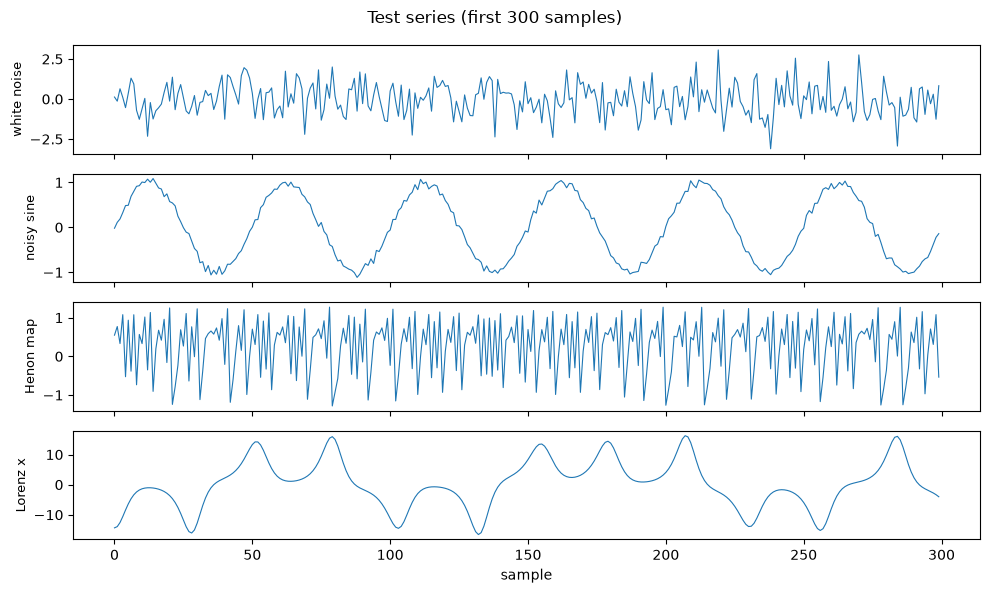

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from nolitisea.entropy.renyi_entropy import renyi_entropy
from nolitisea.entropy.sample_entropy import sample_entropy
from nolitisea.generate.henon import henon
from nolitisea.generate.lorenz import lorenz

rng = np.random.default_rng(0)
N = 3000
t = np.arange(N)

white = rng.standard_normal(N)
sine = np.sin(2 * np.pi * t / 50.0) + 0.05 * rng.standard_normal(N)
henon_x, _ = henon(n=N, discard=2000)
_, lor = lorenz(length=N, discard=2000)
lorenz_x = lor[:, 0]

series = {
    "white noise": white,
    "noisy sine": sine,
    "Henon map": henon_x,
    "Lorenz x": lorenz_x,
}

fig, axes = plt.subplots(4, 1, figsize=(10, 6), sharex=True)
for ax, (name, s) in zip(axes, series.items()):
    ax.plot(t[:300], s[:300], lw=0.8)
    ax.set_ylabel(name, fontsize=9)
axes[-1].set_xlabel("sample")
fig.suptitle("Test series (first 300 samples)")
plt.tight_layout()
plt.show()

## 1. `sample_entropy` — SampEn

```python
sample_entropy(time_series, m=2, r_multiplier=0.2) -> float
```

- `m` — template (embedding) length; templates of length `m` and `m+1` are
  compared;
- `r_multiplier` — the Chebyshev match tolerance is `r = r_multiplier * std(x)`;
- the result is `SampEn = -ln(A / B)`, where `B` counts matching template pairs
  at length `m` and `A` at length `m+1` (self-matches excluded, pairs counted
  with `cKDTree`, so it scales to long series).

Small SampEn means self-similar / predictable (periodic or low-dimensional
deterministic), large SampEn means irregular / unpredictable. If no length-`m+1`
match is found the function returns `np.inf` (choose larger `r`, smaller `m`, or
more data).

In [2]:
print(f"{'series':14s} {'SampEn(m=2, r=0.2*std)':>22s}")
for name, s in series.items():
    se = sample_entropy(s, m=2, r_multiplier=0.2)
    print(f"{name:14s} {se:22.4f}")

series         SampEn(m=2, r=0.2*std)
white noise                    2.1869
noisy sine                     0.3915
Henon map                      0.4549
Lorenz x                       0.3423


White noise is by far the most irregular; the deterministic chaotic series and
the near-periodic sine all show much smaller SampEn.

### Sensitivity to `m` and `r_multiplier`

SampEn depends smoothly on both parameters (it is a *family* of statistics, not
a single universal number): larger `m` and smaller `r` make matching stricter,
which tends to increase SampEn until, eventually, no pairs match and the result
becomes `inf`.

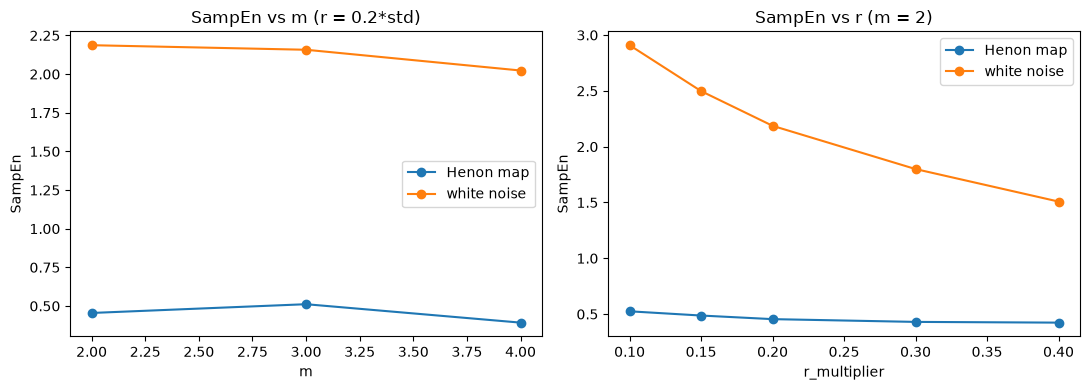

Henon  m=2..4: [0.455, 0.512, 0.392]
noise  m=2..4: [2.187, 2.157, 2.023]


In [3]:
ms = [2, 3, 4]
rs = [0.10, 0.15, 0.20, 0.30, 0.40]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: SampEn vs embedding dimension m
for name, s in [("Henon map", henon_x), ("white noise", white)]:
    vals = [sample_entropy(s, m=m, r_multiplier=0.2) for m in ms]
    axes[0].plot(ms, vals, "o-", label=name)
axes[0].set(xlabel="m", ylabel="SampEn", title="SampEn vs m (r = 0.2*std)")
axes[0].legend()

# Right: SampEn vs tolerance r
for name, s in [("Henon map", henon_x), ("white noise", white)]:
    vals = [sample_entropy(s, m=2, r_multiplier=r) for r in rs]
    axes[1].plot(rs, vals, "o-", label=name)
axes[1].set(xlabel="r_multiplier", ylabel="SampEn", title="SampEn vs r (m = 2)")
axes[1].legend()
plt.tight_layout()
plt.show()

print("Henon  m=2..4:", [round(float(sample_entropy(henon_x, m=m)), 3) for m in ms])
print("noise  m=2..4:", [round(float(sample_entropy(white, m=m)), 3) for m in ms])

In [4]:
# Edge cases:
#  * tolerance too small / dimension too high for the data amount -> no matches
#    at length m+1, and SampEn is +inf;
#  * a constant series has zero variance and gives SampEn = 0.
print("white noise, m=5, r=0.1*std:",
      sample_entropy(white, m=5, r_multiplier=0.1))
print("constant series, m=2:       ",
      sample_entropy(np.ones(500), m=2))

# Practical guidance: the canonical recommendation (Richman & Moorman 2000)
# is r between 0.1 and 0.25 *std, and comparing series with the SAME m, r and
# sampling protocol.

white noise, m=5, r=0.1*std: inf
constant series, m=2:        0.0


## 2. `renyi_entropy` — box-counting Renyi block entropies

```python
renyi_entropy(series, embed=10, delay=1, q=2.0,
              eps_min=None, eps_max=None, eps_count=20) -> dict
```

The (possibly multivariate) series is rescaled to `[0, 1]`, delay-embedded, and
covered by a uniform grid. On a geometric ladder of box sizes `eps` the
order-`q` Renyi entropy of the box occupation is computed for every prefix of
the embedding (embedding level 1 up to `embed`). `q=1` is the Shannon block
entropy; `q=2` (default) relates to the Grassberger-Procaccia correlation
entropy.

The returned dictionary contains:

- `"eps"` — box sizes in data units, shape `(eps_count,)` (descending);
- `"hq"` — block entropies, shape `(n_vars * embed, eps_count)`; row
  `e * n_vars + c` is component `c+1` at embedding level `e+1`;
- `"dhq"` — increments `hq[e] - hq[e-1]` (first row copies `hq[0]`);
- `"components"`, `"embeddings"` — row labels.

Two scalings are read from such tables:

- **entropy rate** `K_q`: in a finite data regime, the increments `dhq` settle
  to a plateau versus embedding dimension — that plateau estimates `K_q`
  (nats per sampling step); for deterministic chaos `K_2` approximates the sum
  of positive Lyapunov exponents;
- **dimension**: the slope of `hq` versus `-ln(eps)` at large embedding is
  related to the correlation dimension;
- white noise has *no* `dhq` plateau: each added embedding dimension
  contributes fresh entropy.

The smallest box sizes are limited by data amount (undersaturation), the
largest boxes by resolution: the plateau is sought in the intermediate
*scaling region*.

In [5]:
N_big = 10000
henon_big, _ = henon(n=N_big, discard=2000)
white_big = rng.standard_normal(N_big)

res = renyi_entropy(henon_big, embed=8, delay=1, q=2.0, eps_count=20)

print("keys:       ", list(res.keys()))
print("eps shape:  ", res["eps"].shape)
print("hq shape:   ", res["hq"].shape, "  (rows = n_vars*embed =", 1 * 8, ")")
print("components: ", res["components"])
print("embeddings: ", res["embeddings"])
print("eps ladder (data units), descending:")
print(np.round(res["eps"], 4))

keys:        ['eps', 'hq', 'dhq', 'components', 'embeddings']
eps shape:   (20,)
hq shape:    (8, 20)   (rows = n_vars*embed = 8 )
components:  [1 1 1 1 1 1 1 1]
embeddings:  [1 2 3 4 5 6 7 8]
eps ladder (data units), descending:
[2.5572e+00 1.2359e+00 5.9730e-01 4.1520e-01 2.8870e-01 2.0070e-01
 1.3950e-01 9.7000e-02 6.7400e-02 4.6900e-02 3.2600e-02 2.2700e-02
 1.5700e-02 1.0900e-02 7.6000e-03 5.3000e-03 3.7000e-03 2.6000e-03
 1.8000e-03 1.2000e-03]


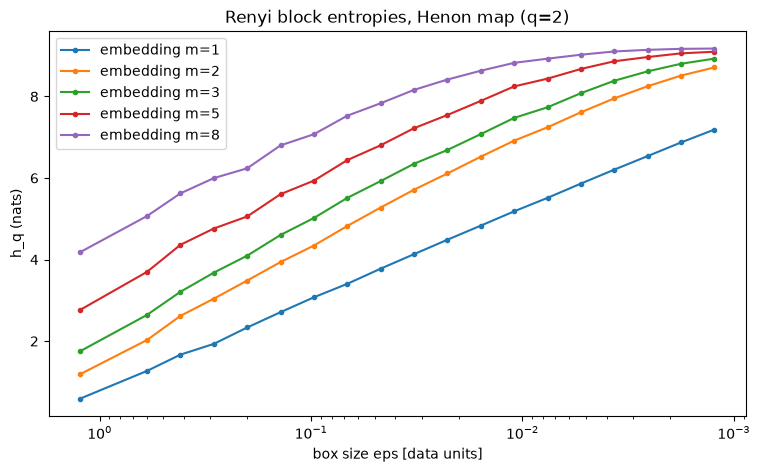

In [6]:
# Block entropy hq versus box size: in the scaling region the curves for
# successive embedding dimensions run roughly parallel (linear growth with
# -ln eps), and merge into a plateau at the coarsest boxes.
m_levels = res["embeddings"]
eps = res["eps"]

fig, ax = plt.subplots(figsize=(9, 5))
for e in [1, 2, 3, 5, 8]:
    ax.plot(eps[1:], res["hq"][e - 1, 1:], "o-", ms=3,
            label=f"embedding m={e}")
ax.set_xscale("log")
ax.set(xlabel="box size eps [data units]", ylabel="h_q (nats)",
       title="Renyi block entropies, Henon map (q=2)")
ax.legend()
plt.gca().invert_xaxis()  # fine boxes to the right
plt.show()

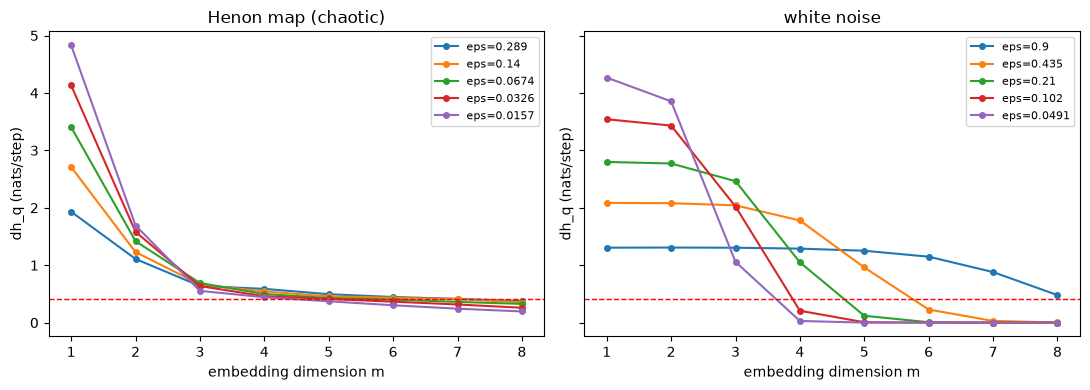

Henon K_2 estimate: 0.414 nats/iteration  (largest Lyapunov exponent: ~0.419)
White noise: the increments stay large for coarse boxes and only collapse where the data run out of neighbours -- no entropy plateau.


In [7]:
# Entropy-rate plateau: plot the increments dhq against embedding dimension
# for a few box sizes in the scaling region.  For the Henon map the increments
# settle around K_2 ~ 0.42 nats/iteration -- close to its largest Lyapunov
# exponent (lambda_1 ~ 0.419).
res_w = renyi_entropy(white_big, embed=8, delay=1, q=2.0, eps_count=20)

cols = [4, 6, 8, 10, 12]      # ladder columns in the scaling region
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, result, title in [(axes[0], res, "Henon map (chaotic)"),
                          (axes[1], res_w, "white noise")]:
    for k in cols:
        ax.plot(np.arange(1, 9), result["dhq"][:, k], "o-", ms=4,
                label=f"eps={result['eps'][k]:.3g}")
    ax.axhline(0.419, color="red", ls="--", lw=1)
    ax.set(xlabel="embedding dimension m", ylabel="dh_q (nats/step)",
           title=title)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# Plateau estimate: median of dhq over embedding levels 4-6 and the mid-ladder
# columns (skip both the coarse and the data-starved fine ends).
K2_henon = np.median(res["dhq"][3:6, 8:12])
print(f"Henon K_2 estimate: {K2_henon:.3f} nats/iteration  "
      f"(largest Lyapunov exponent: ~0.419)")
print("White noise: the increments stay large for coarse boxes and only "
      "collapse where the data run out of neighbours -- no entropy plateau.")

### Order `q`: Shannon (`q=1`) versus correlation (`q=2`) entropy

`q=1` computes the Shannon block entropy (`-sum p ln p`); `q=2` the
correlation-entropy variant (`-ln sum p^2`). Renyi entropies are ordered,
`H_1 >= H_2`, so the Shannon rate is an upper bound on the correlation rate.

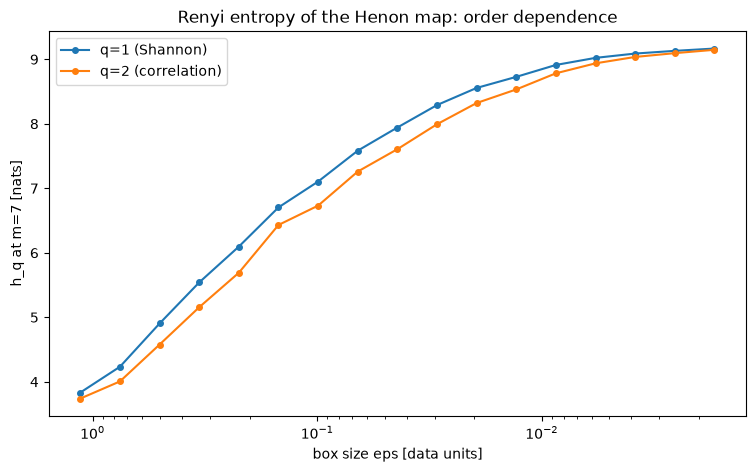

entropy-rate plateaus: K_1 = 0.456, K_2 = 0.426 nats/iteration (K_1 >= K_2 as expected)


In [8]:
res_q1 = renyi_entropy(henon_big, embed=7, delay=1, q=1.0, eps_count=18)
res_q2 = renyi_entropy(henon_big, embed=7, delay=1, q=2.0, eps_count=18)

fig, ax = plt.subplots(figsize=(9, 5))
for result, q in [(res_q1, 1), (res_q2, 2)]:
    ax.plot(result["eps"][1:], result["hq"][-1, 1:], "o-", ms=4,
            label=f"q={q} ({'Shannon' if q == 1 else 'correlation'})")
ax.set_xscale("log")
ax.invert_xaxis()
ax.set(xlabel="box size eps [data units]", ylabel="h_q at m=7 [nats]",
       title="Renyi entropy of the Henon map: order dependence")
ax.legend()
plt.show()

K1 = np.median(res_q1["dhq"][3:6, 7:11])
K2 = np.median(res_q2["dhq"][3:6, 7:11])
print(f"entropy-rate plateaus: K_1 = {K1:.3f}, K_2 = {K2:.3f} nats/iteration "
      f"(K_1 >= K_2 as expected)")

### Multivariate input

Passing a 2-D array (one column per observed component) embeds all components
in an interleaved order. Row `e * n_vars + c` of `hq` holds component `c+1` at
embedding level `e+1`; the `"components"` and `"embeddings"` arrays label every
row.

hq shape: (6, 15)  (n_vars*embed = 2*3)
components : [1 2 1 2 1 2]
embeddings : [1 1 2 2 3 3]


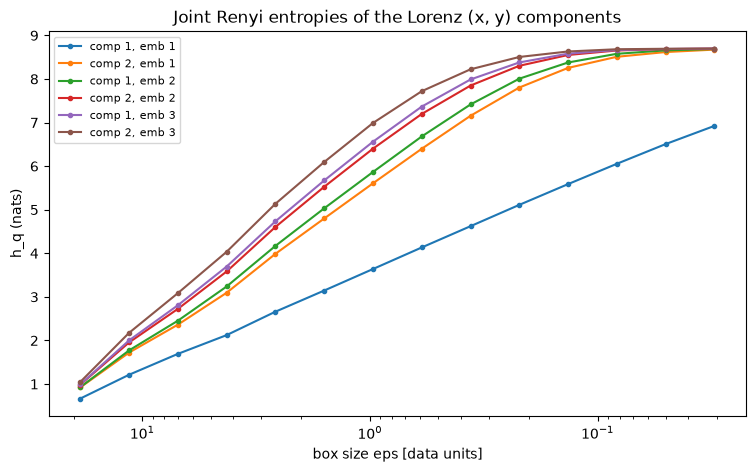

In [9]:
# Observe the x and y coordinates of the Lorenz flow simultaneously.
_, lor_big = lorenz(length=6000, discard=2000)

res_mv = renyi_entropy(lor_big[:, :2], embed=3, delay=1, q=2.0, eps_count=15)
print("hq shape:", res_mv["hq"].shape, " (n_vars*embed = 2*3)")
print("components :", res_mv["components"])
print("embeddings :", res_mv["embeddings"])

fig, ax = plt.subplots(figsize=(9, 5))
for row in range(res_mv["hq"].shape[0]):
    ax.plot(res_mv["eps"][1:], res_mv["hq"][row, 1:], "o-", ms=3,
            label=f"comp {res_mv['components'][row]}, "
                  f"emb {res_mv['embeddings'][row]}")
ax.set_xscale("log")
ax.invert_xaxis()
ax.set(xlabel="box size eps [data units]", ylabel="h_q (nats)",
       title="Joint Renyi entropies of the Lorenz (x, y) components")
ax.legend(fontsize=8)
plt.show()

## Summary

- **`sample_entropy(x, m, r_multiplier)`** returns one complexity number:
  `-ln(A/B)` for length-`m`/`m+1` template matches within Chebyshev tolerance
  `r = r_multiplier * std(x)`. White noise scores highest, periodic and
  chaotic deterministic series much lower; use the same `m`/`r` when comparing
  series, and expect `inf` when matching is too strict for the data amount.
- **`renyi_entropy(series, embed, delay, q, eps_count, ...)`** returns a dict
  with the block-entropy table `"hq"` over box size (geometric ladder, `"eps"`)
  and embedding level, its increments `"dhq"`, and per-row component/embedding
  labels. For chaotic data the increments plateau at the entropy rate `K_q`
  (Henon: ~0.42 nats/step, matching its largest Lyapunov exponent); for white
  noise no plateau exists. `q=1` gives the Shannon rate, `q=2` the
  correlation rate (`K_1 >= K_2`); 2-D input produces interleaved multivariate
  embeddings.